In [ ]:
!pip -q install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.2 MB/s eta 0:00:00


In [ ]:
import re
import math
import random
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
import requests

url = "https://huggingface.co/datasets/ai4bharat/IndicCorpV2/resolve/main/data/gu.txt"

response = requests.get(url, stream=True)

response.raise_for_status()

print("Connected successfully!")

Connected successfully!


In [ ]:
sentences = []

for line in response.iter_lines():

    if line:
        sentence = line.decode("utf-8").strip()

        if sentence:
            sentences.append(sentence)

    if len(sentences) >= 1_000_000:
        break

print("Total sentences:", len(sentences))

print("\nFirst 5 sentences:\n")

for s in sentences[:5]:
    print(s)

Total sentences: 1000000

First 5 sentences:

આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ
મિથેનોલ આવ્યો ક્યાંથી?
આખરે ત્રણ રાજ્યોમાં મળેલ હાર પર કોંગ્રેસ અધ્યક્ષ રાહુલ ગાંધી દ્વારા પ્રથમ પ્રતિક્રિયા આપવામાં આવી છે. તેમણે કહ્યું કે, ત્રિપુરા, નાગાલેન્ડ અને મેઘાલયમાં લોકોના જનાદેશનો સ્વાગત કરીએ છે અને આ ક્ષેત્રના લોકોનો વિશ્વાસ ફરીથી જીતીવા માટે પ્રતિબદ્ધ છીએ.
આ આંકડો માટે, અને વજન ઘટાડવા માટે પ્રકાશનનો દિવસ વિતાવવો ઉપયોગી છે, ઉદાહરણ તરીકે, અઠવાડિયામાં એક વખત. તમારા માટે એક વિકલ્પ પસંદ કરો જે અગવડતાને કારણે નહીં કરે. સૌથી વધુ લોકપ્રિય કીફિર પર અનલોડ છે.
આ ઠેકાઓ પરથી લીમડી તેમજ ઝાલોદના બૂટલેગરો વિદેશી દારૃનો મોટાપાયે જથ્થો ખરીદી મહિસાગર, હાલોલ, ગોધરા, આણંદ, નડિયાદ અને વડોદરા શહેર-જિલ્લામાં ઠાલવે છે. આબુથી આવતો દારૃનો જથ્થો સાંચોર તેમજ પાલનપુર થઈ મહેસાણામાં રીટા અને વિરસિંહને ત્યાં ઉતારવામાં આવે છે, જ્યાંથી અમદાવાદ તેમજ ઉત્તર ગુજરાતમાં દારૃ સપ્લાઈ થાય છે. રાજસ્થાનના બિચ્છુવાડાથી શામળાજી બોર્ડર થઈ હિંમતનગર, ગાંધીનગર અને અમદાવાદમાં બૂટલેગર સુનિલ, વિનોદ, દિલીપ અને રબારી દ્વારા મોટા

In [ ]:
print(sentences[0])
print(type(sentences[0]))

આ વીડિયો જુઓ: ઊંઝા માર્કેટયાર્ડ આજથી 25 જુલાઈ સુધી બંધ
<class 'str'>


In [ ]:
import random

random.seed(42)
random.shuffle(sentences)

train_sentences = sentences[:800000]
dev_sentences = sentences[800000:900000]
test_sentences = sentences[900000:1000000]

print("Training sentences:", len(train_sentences))
print("Development sentences:", len(dev_sentences))
print("Testing sentences:", len(test_sentences))

Training sentences: 800000
Development sentences: 100000
Testing sentences: 100000


In [ ]:
import re

def tokenize(sentence):
    return re.findall(r'\w+|[.,!?;:]', sentence.lower())

print(tokenize(train_sentences[0]))

['સ', 'મ', 'ર', 'ટફ', 'ન', 'લ', 'વ', 'છ', 'પર', 'ત', 'તમન', 'આ', 'નથ', 'ખબર', 'ત', 'ક', 'ઇ', 'જ', 'નથ', 'ખબર']


In [ ]:
vocab = set()

for sentence in train_sentences:
    vocab.update(tokenize(sentence))

vocab.update(["<UNK>", "<s>", "</s>"])

V = len(vocab)

print("Vocabulary size:", V)

Vocabulary size: 113862


In [ ]:
train_tokens = []

for sentence in train_sentences:
    tokens = tokenize(sentence)
    tokens = [w if w in vocab else "<UNK>" for w in tokens]
    train_tokens.append(tokens)

print("Tokenization completed!")
print(train_tokens[0])

Tokenization completed!
['સ', 'મ', 'ર', 'ટફ', 'ન', 'લ', 'વ', 'છ', 'પર', 'ત', 'તમન', 'આ', 'નથ', 'ખબર', 'ત', 'ક', 'ઇ', 'જ', 'નથ', 'ખબર']


In [ ]:
from collections import Counter

models = {}

for n in range(1, 5):

    ngram_counts = Counter()

    for tokens in train_tokens:

        padded = ["<s>"] * (n - 1) + tokens + ["</s>"]

        for i in range(len(padded) - n + 1):
            ngram = tuple(padded[i:i+n])
            ngram_counts[ngram] += 1

    models[n] = ngram_counts

    print(
        f"{n}-gram: {len(ngram_counts):,} unique n-grams"
    )

1-gram: 113,860 unique n-grams
2-gram: 1,358,575 unique n-grams
3-gram: 6,602,112 unique n-grams
4-gram: 18,556,563 unique n-grams


In [ ]:
context_counts = {}

for n in range(2, 5):

    counts = Counter()

    for ngram, count in models[n].items():
        context = ngram[:-1]
        counts[context] += count

    context_counts[n] = counts

    print(
        f"{n}-gram contexts:",
        f"{len(counts):,}"
    )

2-gram contexts: 113,860
3-gram contexts: 1,353,030
4-gram contexts: 6,568,516


In [ ]:
def unsmoothed_probability(ngram, n):

    if n == 1:
        total = sum(models[1].values())
        return models[1].get(ngram, 0) / total

    context = ngram[:-1]

    if context_counts[n].get(context, 0) == 0:
        return 0

    return models[n].get(ngram, 0) / context_counts[n][context]

In [ ]:
def add_one_probability(ngram, n):

    if n == 1:

        total = sum(models[1].values())

        return (
            models[1].get(ngram, 0) + 1
        ) / (
            total + V
        )

    context = ngram[:-1]

    return (
        models[n].get(ngram, 0) + 1
    ) / (
        context_counts[n].get(context, 0) + V
    )

In [ ]:
K = 0.1

def add_k_probability(ngram, n):

    if n == 1:

        total = sum(models[1].values())

        return (
            models[1].get(ngram, 0) + K
        ) / (
            total + K * V
        )

    context = ngram[:-1]

    return (
        models[n].get(ngram, 0) + K
    ) / (
        context_counts[n].get(context, 0) + K * V
    )

In [ ]:
lambdas = {
    1: [1.0],
    2: [0.4, 0.6],
    3: [0.2, 0.3, 0.5],
    4: [0.1, 0.2, 0.3, 0.4]
}

print(lambdas)

{1: [1.0], 2: [0.4, 0.6], 3: [0.2, 0.3, 0.5], 4: [0.1, 0.2, 0.3, 0.4]}


In [ ]:
def interpolated_probability(ngram, n):

    if n == 1:
        return add_k_probability(ngram, 1)

    probability = 0.0

    for order in range(1, n + 1):

        subgram = ngram[-order:]

        p = add_k_probability(
            subgram,
            order
        )

        probability += (
            lambdas[n][order - 1] * p
        )

    return probability

In [ ]:
D = 0.75

# Number of unique contexts that precede each word
continuation_counts = Counter()

for bigram in models[2]:
    word = bigram[1]
    continuation_counts[word] += 1

total_unique_bigrams = len(models[2])

# Number of unique followers for each context
unique_followers = {}

for n in range(2, 5):

    unique_followers[n] = Counter()

    for ngram in models[n]:
        context = ngram[:-1]
        unique_followers[n][context] += 1

print("Kneser-Ney statistics ready!")
print("Discount:", D)
print("Unique bigrams:", total_unique_bigrams)

Kneser-Ney statistics ready!
Discount: 0.75
Unique bigrams: 1358575


In [ ]:
def kneser_ney_probability(ngram, n):

    # Unigram continuation probability
    if n == 1:

        word = ngram[0]

        count = continuation_counts.get(word, 0)

        if count == 0:
            return 1e-12

        return count / total_unique_bigrams

    # Higher-order n-grams
    context = ngram[:-1]

    context_count = context_counts[n].get(
        context, 0
    )

    ngram_count = models[n].get(
        ngram, 0
    )

    # Backoff for unseen context
    if context_count == 0:

        return kneser_ney_probability(
            ngram[1:],
            n - 1
        )

    # Discounted probability
    first_term = max(
        ngram_count - D,
        0
    ) / context_count

    # Number of unique followers
    followers = unique_followers[n].get(
        context,
        0
    )

    # Backoff weight
    lambda_value = (
        D * followers
    ) / context_count

    # Lower-order probability
    lower_probability = kneser_ney_probability(
        ngram[1:],
        n - 1
    )

    probability = (
        first_term
        + lambda_value * lower_probability
    )

    # Prevent zero probability
    return max(probability, 1e-12)

In [ ]:
dev_tokens = [
    [
        w if w in vocab else "<UNK>"
        for w in tokenize(sentence)
    ]
    for sentence in dev_sentences[:5000]
]

print("Development sentences used:", len(dev_tokens))

Development sentences used: 5000


In [ ]:
import math

def calculate_perplexity(
    token_sentences,
    n,
    method
):

    total_log_probability = 0.0
    total_tokens = 0

    for sentence in token_sentences:

        tokens = (
            ["<s>"] * (n - 1)
            + sentence
            + ["</s>"]
        )

        for i in range(len(tokens) - n + 1):

            ngram = tuple(
                tokens[i:i+n]
            )

            if method == "Unsmoothed":
                p = unsmoothed_probability(
                    ngram, n
                )

            elif method == "Add-1":
                p = add_one_probability(
                    ngram, n
                )

            elif method == "Add-K":
                p = add_k_probability(
                    ngram, n
                )

            elif method == "Interpolated":
                p = interpolated_probability(
                    ngram, n
                )

            elif method == "Kneser-Ney":
                p = kneser_ney_probability(
                    ngram, n
                )

            if p <= 0:
                return float("inf")

            total_log_probability += math.log(p)
            total_tokens += 1

    return math.exp(
        -total_log_probability / total_tokens
    )

In [21]:
methods = [
    "Unsmoothed",
    "Add-1",
    "Add-K",
    "Interpolated",
    "Kneser-Ney"
]

results = []

for n in range(1, 5):

    print("\n" + "=" * 50)
    print(f"{n}-GRAM MODEL")
    print("=" * 50)

    for method in methods:

        print("Calculating:", method)

        pp = calculate_perplexity(
            dev_tokens,
            n,
            method
        )

        results.append({
            "N": n,
            "Model": f"{n}-gram",
            "Smoothing": method,
            "Perplexity": pp
        })

        print(
            f"Perplexity: {pp:.4f}"
        )


1-GRAM MODEL
Calculating: Unsmoothed
Perplexity: inf
Calculating: Add-1
Perplexity: 140.0563
Calculating: Add-K
Perplexity: 140.2741
Calculating: Interpolated
Perplexity: 140.2741
Calculating: Kneser-Ney
Perplexity: 336.5183

2-GRAM MODEL
Calculating: Unsmoothed
Perplexity: inf
Calculating: Add-1
Perplexity: 104.5217
Calculating: Add-K
Perplexity: 72.9687
Calculating: Interpolated
Perplexity: 75.2275
Calculating: Kneser-Ney
Perplexity: 60.6485

3-GRAM MODEL
Calculating: Unsmoothed
Perplexity: inf
Calculating: Add-1
Perplexity: 426.6692
Calculating: Add-K
Perplexity: 122.3247
Calculating: Interpolated
Perplexity: 66.2983
Calculating: Kneser-Ney
Perplexity: 34.2382

4-GRAM MODEL
Calculating: Unsmoothed
Perplexity: inf
Calculating: Add-1
Perplexity: 3327.7909
Calculating: Add-K
Perplexity: 688.4681
Calculating: Interpolated
Perplexity: 84.6384
Calculating: Kneser-Ney
Perplexity: 26.1738


In [22]:
results_df = pd.DataFrame(results)

results_df

,N,Model,Smoothing,Perplexity
0,1,1-gram,Unsmoothed,inf
1,1,1-gram,Add-1,140.056269
2,1,1-gram,Add-K,140.274128
3,1,1-gram,Interpolated,140.274128
4,1,1-gram,Kneser-Ney,336.518284
5,2,2-gram,Unsmoothed,inf
6,2,2-gram,Add-1,104.521741
7,2,2-gram,Add-K,72.968683
8,2,2-gram,Interpolated,75.227487
9,2,2-gram,Kneser-Ney,60.648472


In [23]:
comparison = results_df.pivot(
    index="Model",
    columns="Smoothing",
    values="Perplexity"
)

comparison

Smoothing,Add-1,Add-K,Interpolated,Kneser-Ney,Unsmoothed
Model,,,,,
1-gram,140.056269,140.274128,140.274128,336.518284,inf
2-gram,104.521741,72.968683,75.227487,60.648472,inf
3-gram,426.669232,122.324716,66.298301,34.238163,inf
4-gram,3327.790857,688.468059,84.638423,26.173822,inf


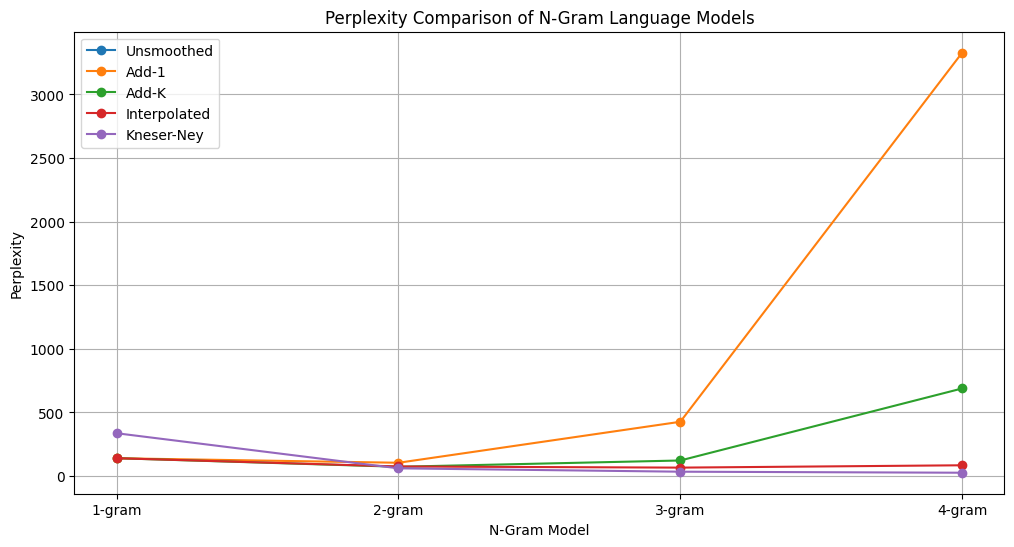

In [24]:
plt.figure(figsize=(12, 6))

for method in methods:

    plt.plot(
        comparison.index,
        comparison[method],
        marker="o",
        label=method
    )

plt.xlabel("N-Gram Model")
plt.ylabel("Perplexity")
plt.title("Perplexity Comparison of N-Gram Language Models")

plt.legend()
plt.grid(True)
plt.show()

In [25]:
valid_results = results_df[
    results_df["Perplexity"] != float("inf")
]

best = valid_results.loc[
    valid_results["Perplexity"].idxmin()
]

print("BEST MODEL")
print("=" * 40)
print("Model:", best["Model"])
print("Smoothing:", best["Smoothing"])
print("Perplexity:", best["Perplexity"])

BEST MODEL
Model: 4-gram
Smoothing: Kneser-Ney
Perplexity: 26.173822379988867


In [26]:
test_tokens = [
    [
        w if w in vocab else "<UNK>"
        for w in tokenize(sentence)
    ]
    for sentence in test_sentences[:5000]
]

best_n = int(best["N"])
best_method = best["Smoothing"]

test_pp = calculate_perplexity(
    test_tokens,
    best_n,
    best_method
)

print("FINAL TEST RESULT")
print("=" * 40)
print("Model:", best["Model"])
print("Smoothing:", best_method)
print("Test Perplexity:", test_pp)

FINAL TEST RESULT
Model: 4-gram
Smoothing: Kneser-Ney
Test Perplexity: 25.78961915213643


In [27]:
print("=" * 70)
print("FINAL PERPLEXITY COMPARISON")
print("=" * 70)

for _, row in results_df.iterrows():

    print(
        f"{row['Model']:8s} | "
        f"{row['Smoothing']:15s} | "
        f"Perplexity = {row['Perplexity']:.4f}"
    )

FINAL PERPLEXITY COMPARISON
1-gram   | Unsmoothed      | Perplexity = inf
1-gram   | Add-1           | Perplexity = 140.0563
1-gram   | Add-K           | Perplexity = 140.2741
1-gram   | Interpolated    | Perplexity = 140.2741
1-gram   | Kneser-Ney      | Perplexity = 336.5183
2-gram   | Unsmoothed      | Perplexity = inf
2-gram   | Add-1           | Perplexity = 104.5217
2-gram   | Add-K           | Perplexity = 72.9687
2-gram   | Interpolated    | Perplexity = 75.2275
2-gram   | Kneser-Ney      | Perplexity = 60.6485
3-gram   | Unsmoothed      | Perplexity = inf
3-gram   | Add-1           | Perplexity = 426.6692
3-gram   | Add-K           | Perplexity = 122.3247
3-gram   | Interpolated    | Perplexity = 66.2983
3-gram   | Kneser-Ney      | Perplexity = 34.2382
4-gram   | Unsmoothed      | Perplexity = inf
4-gram   | Add-1           | Perplexity = 3327.7909
4-gram   | Add-K           | Perplexity = 688.4681
4-gram   | Interpolated    | Perplexity = 84.6384
4-gram   | Kneser-Ney      |